Dataset:
                                                 url        type
0                                   br-icloud.com.br    phishing
1                mp3raid.com/music/krizz_kaliko.html      benign
2                    bopsecrets.org/rexroth/cr/1.htm      benign
3  http://www.garage-pirenne.be/index.php?option=...  defacement
4  http://adventure-nicaragua.net/index.php?optio...  defacement

Dataset Shape:
(651191, 2)

Original URL Classes:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

Binary Class Distribution:
label
0    428103
1    223088
Name: count, dtype: int64

Extracted URL Features:
   url_length  domain_length  dot_count  hyphen_count  underscore_count  \
0          16             16          2             1                 0   
1          35             11          2             0                 1   
2          31             14          2             0                 0   
3          88             

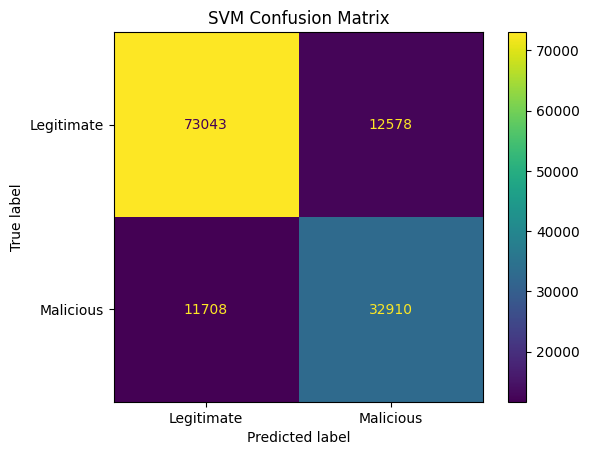

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)



data = pd.read_csv("malicious_phish.csv")

print("Dataset:")
print(data.head())

print("\nDataset Shape:")
print(data.shape)

print("\nOriginal URL Classes:")
print(data["type"].value_counts())


data["label"] = (data["type"] != "benign").astype(int)

print("\nBinary Class Distribution:")
print(data["label"].value_counts())


urls = data["url"].fillna("").astype(str)


features = pd.DataFrame()

features["url_length"] = urls.str.len()

features["domain_length"] = (
    urls.str.split("/").str[0].str.len()
)

features["dot_count"] = urls.str.count(r"\.")

features["hyphen_count"] = urls.str.count("-")

features["underscore_count"] = urls.str.count("_")

features["slash_count"] = urls.str.count("/")

features["question_count"] = urls.str.count(r"\?")

features["equal_count"] = urls.str.count("=")

features["at_count"] = urls.str.count("@")

features["ampersand_count"] = urls.str.count("&")

features["digit_count"] = urls.str.count(r"\d")

features["special_char_count"] = urls.str.count(
    r"[^A-Za-z0-9]"
)

features["has_https"] = (
    urls.str.lower().str.startswith("https").astype(int)
)

features["has_ip"] = urls.str.contains(
    r"(?:\d{1,3}\.){3}\d{1,3}",
    regex=True
).astype(int)


print("\nExtracted URL Features:")
print(features.head())

print("\nFeature Dataset Shape:")
print(features.shape)


target = data["label"]

print("\nTarget Classes:")
print(target.value_counts())


X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "svm",
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=42,
            max_iter=5000
        )
    )
])

model.fit(X_train, y_train)

print("\nSVM Model Trained Successfully.")

y_pred = model.predict(X_test)

print("\nPredictions Completed.")

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(accuracy)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Legitimate", "Malicious"]
    )
)


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Malicious"]
)

disp.plot()

plt.title("SVM Confusion Matrix")
plt.show()